# CS3807 Experiment 5 — Merged Notebook (All Tasks)

This notebook merges three separate notebooks into one, in the order they were originally meant to be run:

1. **`deep_5.ipynb`** — Tasks 2–6 (Plots 1, 3, 5, 6, 9)
2. **`CS3807_Exp5_Remaining_Tasks.ipynb`** — Task 6 continued (Plot 10) + Task 7 (Plots 11–12)
3. **`CS3807_Exp5_Tasks_8_9_10.ipynb`** — Tasks 8, 9, 10 + Additional Exercise (Plots 13–15)

No cells were removed or altered — every code, markdown, and output cell from all three originals is preserved below, in sequence.

⚠️ **Because you said you can't train everything in one sitting**, this merge does **not** change the fact that you still need to restart the runtime and re-run the setup cells (`Step 0` / `Step 1` / `Step 2`) at the checkpoints marked in the original notebooks. The checkpoint helpers (`save_result` / `load_result`, saving to Google Drive) are still what carries results between sessions — merging the files just puts everything in one place so you don't have to juggle three separate documents. Simply run Part 1 in one session, restart and skip down to Part 2 in the next session (re-running its Step 0/1/2 cells first), and so on for Part 3.


---
## Part 1 — Tasks 2–6 (from `deep_5.ipynb`)
---

In [ ]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.


In [ ]:
!pip install -U -q importlib_resources

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.NKUYQD_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.NKUYQD_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of classes (breeds): 37
Train+val size: 3680
Test size: 3669
Final train size: 2944


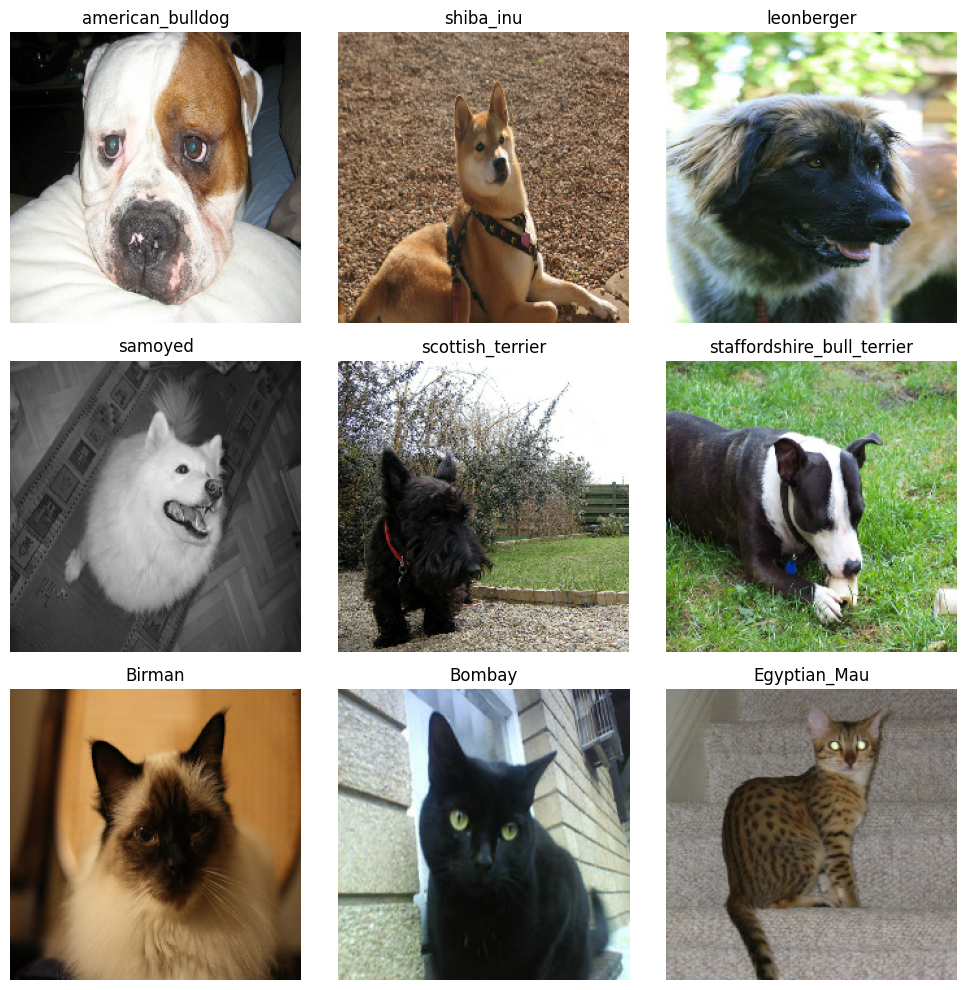

In [ ]:
# ============================================================
# CS3807 - Experiment 5: Setup
# ============================================================
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

# ---- Load Oxford-IIIT Pet dataset ----
(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True   # returns (image, label) pairs
)

num_classes = ds_info.features['label'].num_classes
print("Number of classes (breeds):", num_classes)
print("Train+val size:", ds_info.splits['train'].num_examples)
print("Test size:", ds_info.splits['test'].num_examples)

# ---- Split train_full into train/validation (80/20) ----
train_size = int(0.8 * ds_info.splits['train'].num_examples)

ds_train_full = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full.take(train_size)
ds_val = ds_train_full.skip(train_size)

print("Final train size:", train_size)

# ---- Preprocessing function ----
def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    # MobileNetV2 preprocessing: scales pixels to [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

# ---- Sanity check: visualize a batch ----
class_names = ds_info.features['label'].names

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        img = (images[i].numpy() + 1) / 2.0  # undo [-1,1] scaling for display
        plt.imshow(img)
        label_idx = np.argmax(labels[i].numpy())
        plt.title(class_names[label_idx])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Task 2: Weight Initialization Comparison
# ============================================================
from tensorflow.keras import layers, models, initializers
import time

EPOCHS_INIT = 10  # keep modest for comparison runs; bump up later if time allows

def build_model(init_name):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # feature extraction only for this comparison

    if init_name == 'zero':
        kernel_init = initializers.Zeros()
    elif init_name == 'random':
        kernel_init = initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED)
    elif init_name == 'xavier':
        kernel_init = initializers.GlorotUniform(seed=SEED)
    elif init_name == 'he':
        kernel_init = initializers.HeNormal(seed=SEED)
    else:
        raise ValueError(init_name)

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_initializer=kernel_init)(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_initializer=kernel_init)(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

init_methods = ['zero', 'random', 'xavier', 'he']
init_histories = {}

for method in init_methods:
    print(f"\n{'='*50}\nTraining with {method.upper()} initialization\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_model(method)
    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_INIT,
        verbose=1
    )
    elapsed = time.time() - start
    init_histories[method] = {'history': history.history, 'time': elapsed}
    print(f"{method} took {elapsed:.1f}s")


Training with ZERO initialization
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 197ms/step - accuracy: 0.0258 - loss: 3.6113 - val_accuracy: 0.0258 - val_loss: 3.6108
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.0251 - loss: 3.6112 - val_accuracy: 0.0177 - val_loss: 3.6115
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.0255 - loss: 3.6113 - val_accuracy: 0.0204 - val_loss: 3.6116
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.0275 - loss: 3.6112 - val_accuracy: 0.0217 - val_loss: 3.6111
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.0255 - loss: 3.6110 - val_accuracy: 0.0204 - val_loss: 3.6119
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.0262 - loss: 3.6112 - val_accuracy: 0.0177 - val_loss: 3.6123
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.0262 - loss: 3.6113 - val_accuracy: 0.0258 - val_loss: 3.6117
Epoch 8/10
92

In [ ]:
# ---- Plot 1: Training Loss vs Epoch (all initializations) ----
plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(init_histories[method]['history']['loss'], label=method)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs Epoch (Weight Initialization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot1_init_loss.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Validation Accuracy vs Epoch (all initializations) ----
plt.figure(figsize=(8, 5))
for method in init_methods:
    acc = [a * 100 for a in init_histories[method]['history']['val_accuracy']]
    plt.plot(acc, label=method)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs Epoch (Weight Initialization)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot2_init_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'init_methods' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# ============================================================
# Task 3: Regularization Comparison
# ============================================================
from tensorflow.keras import regularizers

EPOCHS_REG = 20  # longer run so overfitting has room to show up

def build_reg_model(reg_type):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    if reg_type == 'none':
        x = layers.Dense(128, activation='relu')(x)
    elif reg_type == 'l2':
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-3))(x)
    elif reg_type == 'dropout':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif reg_type == 'batchnorm':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
    else:
        raise ValueError(reg_type)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

reg_types = ['none', 'l2', 'dropout', 'batchnorm']
reg_histories = {}

for reg in reg_types:
    print(f"\n{'='*50}\nTraining with regularization: {reg.upper()}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_reg_model(reg)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_REG,
        verbose=1
    )
    reg_histories[reg] = history.history


Training with regularization: NONE
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - accuracy: 0.7272 - loss: 1.0481 - val_accuracy: 0.9035 - val_loss: 0.3199
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - accuracy: 0.9280 - loss: 0.2523 - val_accuracy: 0.9416 - val_loss: 0.2119
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.9429 - loss: 0.1754 - val_accuracy: 0.9511 - val_loss: 0.1489
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9732 - loss: 0.1017 - val_accuracy: 0.9783 - val_loss: 0.0866
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.9837 - loss: 0.0698 - val_accuracy: 0.9837 - val_loss: 0.0758
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9888 - loss: 0.0510 - val_accuracy: 0.9864 - val_loss: 0.0620
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9932 - loss: 0.0369 - val_accuracy: 0.9905 - val_loss: 0.0449
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accura

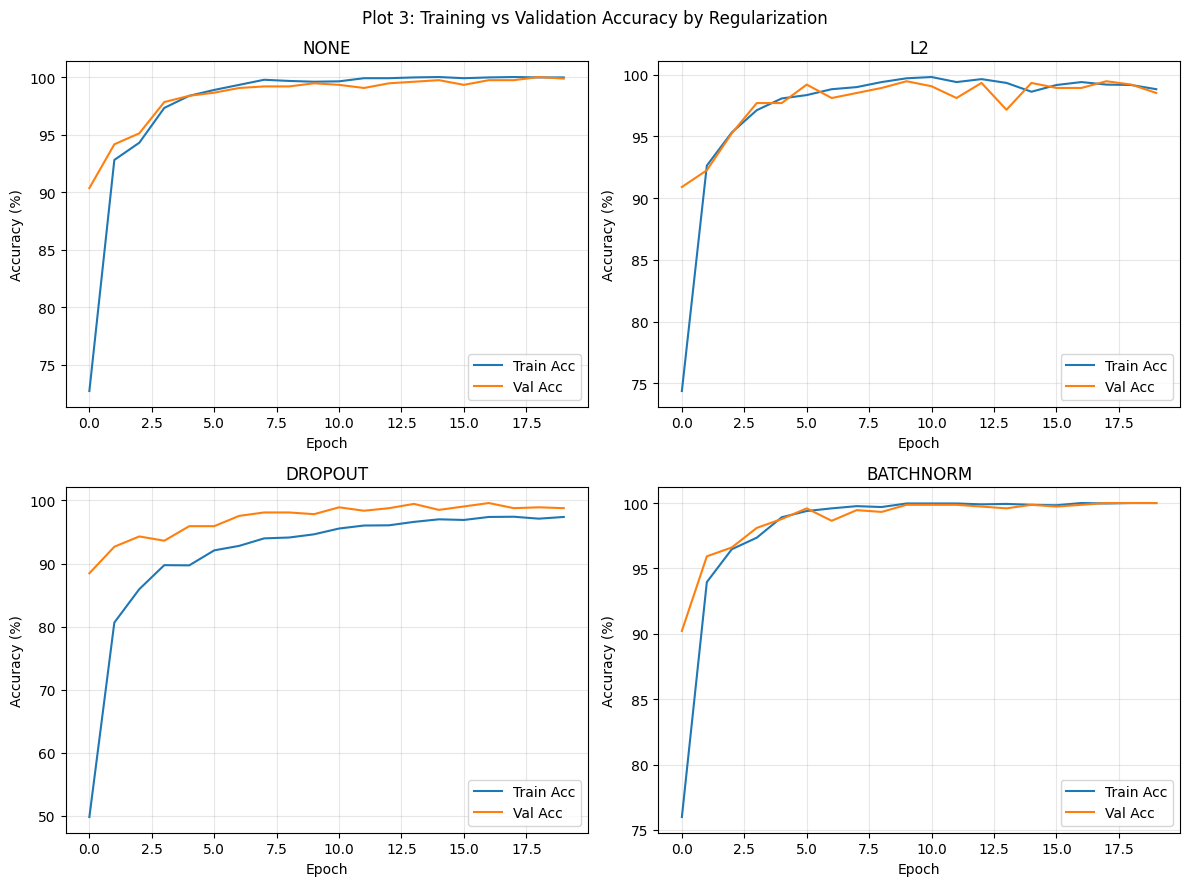

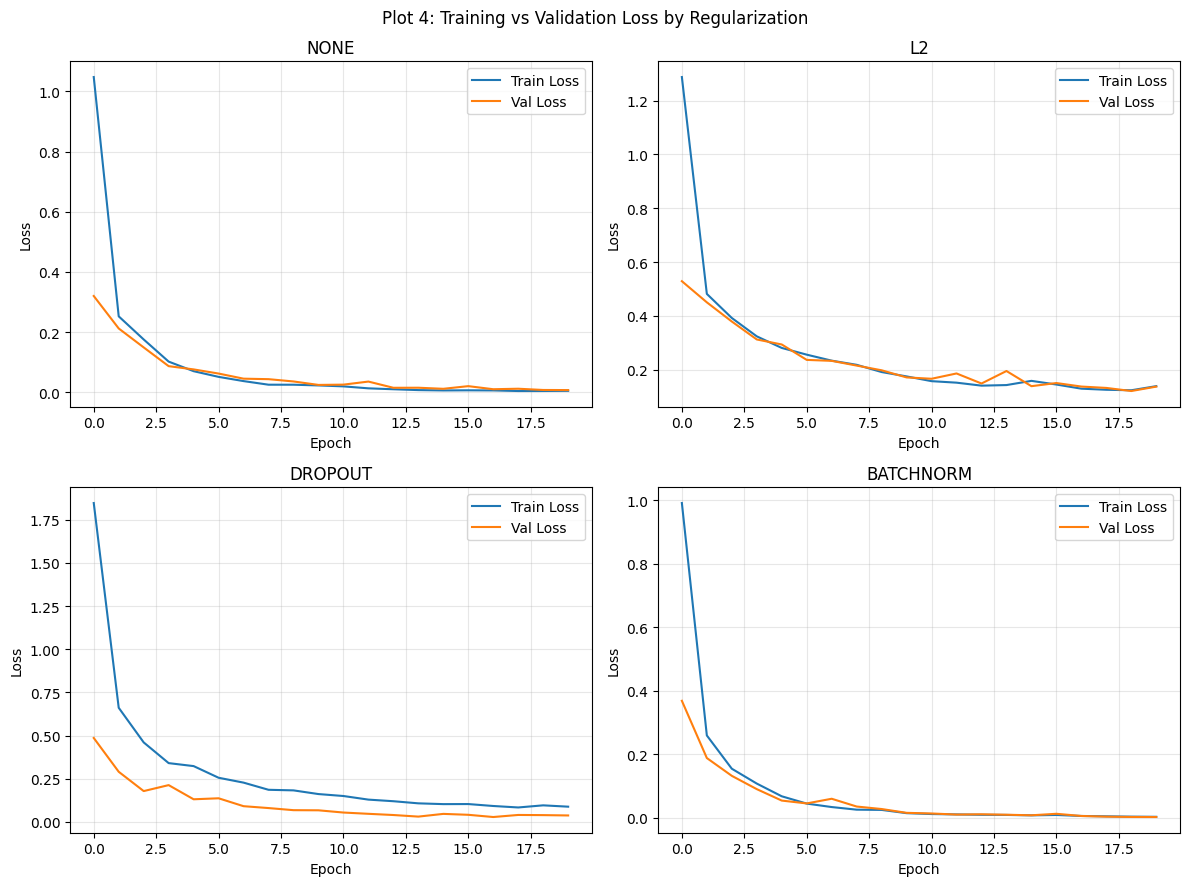

Config      Final Train Acc   Final Val Acc   Gap     
none        99.97             99.86           0.10    
l2          98.81             98.51           0.31    
dropout     97.38             98.78           -1.39   
batchnorm   100.00            100.00          0.00    


In [ ]:
# ---- Plot 3: Training and Validation Accuracy vs Epoch ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, reg in enumerate(reg_types):
    h = reg_histories[reg]
    axes[i].plot([a*100 for a in h['accuracy']], label='Train Acc')
    axes[i].plot([a*100 for a in h['val_accuracy']], label='Val Acc')
    axes[i].set_title(f'{reg.upper()}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy (%)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Plot 3: Training vs Validation Accuracy by Regularization')
plt.tight_layout()
plt.savefig('plot3_reg_accuracy.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 4: Training and Validation Loss vs Epoch ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, reg in enumerate(reg_types):
    h = reg_histories[reg]
    axes[i].plot(h['loss'], label='Train Loss')
    axes[i].plot(h['val_loss'], label='Val Loss')
    axes[i].set_title(f'{reg.upper()}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Plot 4: Training vs Validation Loss by Regularization')
plt.tight_layout()
plt.savefig('plot4_reg_loss.', dpi=150, bbox_inches='tight')
plt.show()

# ---- Generalization gap summary table ----
print(f"{'Config':<12}{'Final Train Acc':<18}{'Final Val Acc':<16}{'Gap':<8}")
for reg in reg_types:
    h = reg_histories[reg]
    train_acc = h['accuracy'][-1] * 100
    val_acc = h['val_accuracy'][-1] * 100
    print(f"{reg:<12}{train_acc:<18.2f}{val_acc:<16.2f}{train_acc-val_acc:<8.2f}")

In [ ]:
# ============================================================
# Task 4a: Batch Normalization - Numerical Verification
# ============================================================
x = np.array([2, 4, 6, 8], dtype=np.float32)

mu_B = np.mean(x)
var_B = np.var(x)  # population variance (divides by m, matches the doc's formula)
epsilon = 1e-8

x_hat = (x - mu_B) / np.sqrt(var_B + epsilon)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"Batch mean (μ_B): {mu_B}")
print(f"Batch variance (σ²_B): {var_B}")
print(f"Std dev: {np.sqrt(var_B):.3f}")
print(f"Normalized (x̂): {x_hat}")
print(f"Output (γ=1, β=0): {y}")

# Cross-check against Keras's own BatchNormalization layer
bn_layer = layers.BatchNormalization()
x_reshaped = x.reshape(1, 4, 1)  # (batch, features, channels) - toy shape
bn_out = bn_layer(x_reshaped, training=True)
print("\nKeras BN layer output (sanity check):", bn_out.numpy().flatten())

Batch mean (μ_B): 5.0
Batch variance (σ²_B): 5.0
Std dev: 2.236
Normalized (x̂): [-1.3416407 -0.4472136  0.4472136  1.3416407]
Output (γ=1, β=0): [-1.3416407 -0.4472136  0.4472136  1.3416407]

Keras BN layer output (sanity check): [-1.3415067  -0.44716895  0.44716883  1.3415065 ]



Training without_bn
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.7368 - loss: 1.0529 - val_accuracy: 0.9049 - val_loss: 0.3075
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.9239 - loss: 0.2478 - val_accuracy: 0.9606 - val_loss: 0.1797
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9511 - loss: 0.1669 - val_accuracy: 0.9755 - val_loss: 0.1178
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.9674 - loss: 0.1157 - val_accuracy: 0.9823 - val_loss: 0.0986
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9847 - loss: 0.0675 - val_accuracy: 0.9864 - val_loss: 0.0657
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9908 - loss: 0.0476 - val_accuracy: 0.9864 - val_loss: 0.0549
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - accuracy: 0.9888 - loss: 0.0480 - val_accuracy: 0.9918 - val_loss: 0.0457
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9980 - lo

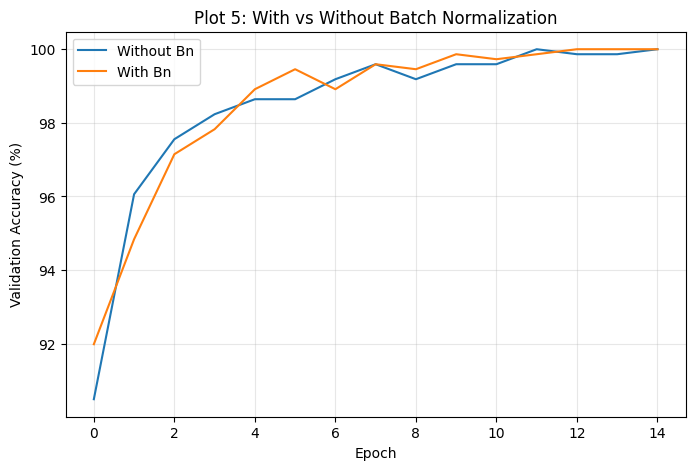

In [ ]:
# ============================================================
# Task 4b: Plot 5 - With vs Without Batch Normalization
# ============================================================
EPOCHS_BN = 15

def build_bn_compare_model(use_bn):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bn_histories = {}
for use_bn, label in [(False, 'without_bn'), (True, 'with_bn')]:
    print(f"\n{'='*50}\nTraining {label}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_bn_compare_model(use_bn)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_BN, verbose=1)
    bn_histories[label] = history.history

# ---- Plot 5 ----
plt.figure(figsize=(8, 5))
for label in ['without_bn', 'with_bn']:
    acc = [a * 100 for a in bn_histories[label]['val_accuracy']]
    plt.plot(acc, label=label.replace('_', ' ').title())
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot5_bn_comparison.eps', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Task 5: Optimizer Comparison
# ============================================================
EPOCHS_OPT = 15

def build_opt_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

optimizers_dict = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=1e-3),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=1e-3),
    'Adam': tf.keras.optimizers.Adam(learning_rate=1e-3),
}

opt_histories = {}
opt_summary = []

for name, opt in optimizers_dict.items():
    print(f"\n{'='*50}\nTraining with {name}\n{'='*50}")
    tf.keras.backend.clear_session()
    model = build_opt_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_OPT, verbose=1)
    elapsed = time.time() - start

    val_acc = history.history['val_accuracy']
    best_val_acc = max(val_acc)
    # epoch to converge: first epoch reaching within 1% of best val acc
    converge_epoch = next(i for i, a in enumerate(val_acc) if a >= best_val_acc - 0.01) + 1

    opt_histories[name] = history.history
    opt_summary.append({
        'Optimizer': name,
        'Final Loss': history.history['loss'][-1],
        'Best Val Accuracy': best_val_acc * 100,
        'Epoch to Converge': converge_epoch,
        'Time (s)': elapsed
    })


Training with SGD
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 250ms/step - accuracy: 0.0353 - loss: 3.9717 - val_accuracy: 0.0503 - val_loss: 3.6371
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.0465 - loss: 3.7432 - val_accuracy: 0.0897 - val_loss: 3.4996
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.0683 - loss: 3.5734 - val_accuracy: 0.1250 - val_loss: 3.3457
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.0890 - loss: 3.4372 - val_accuracy: 0.1644 - val_loss: 3.2279
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.1026 - loss: 3.3254 - val_accuracy: 0.2120 - val_loss: 3.1354
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.1413 - loss: 3.1989 - val_accuracy: 0.2867 - val_loss: 3.0056
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.1756 - loss: 3.0914 - val_accuracy: 0.3261 - val_loss: 2.9192
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.1940 - loss

In [ ]:
# ---- Plot 6: Training Loss vs Epoch ----
plt.figure(figsize=(8, 5))
for name in optimizers_dict:
    plt.plot(opt_histories[name]['loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch (Optimizers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot6_opt_loss.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 7: Validation Accuracy vs Epoch ----
plt.figure(figsize=(8, 5))
for name in optimizers_dict:
    acc = [a * 100 for a in opt_histories[name]['val_accuracy']]
    plt.plot(acc, label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch (Optimizers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot7_opt_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

# ---- Fill in the required table from the doc ----
import pandas as pd
opt_table = pd.DataFrame(opt_summary)
opt_table = opt_table[['Optimizer', 'Final Loss', 'Best Val Accuracy', 'Epoch to Converge', 'Time (s)']]
print(opt_table.to_string(index=False))
opt_table.to_csv('optimizer_comparison_table.csv', index=False)

NameError: name 'plt' is not defined


--- Learning Rate: 0.001 ---
Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.6471 - loss: 1.3446 - val_accuracy: 0.9103 - val_loss: 0.3148
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.8791 - loss: 0.3995 - val_accuracy: 0.9266 - val_loss: 0.2222
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.9161 - loss: 0.2604 - val_accuracy: 0.9511 - val_loss: 0.1672
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9280 - loss: 0.2121 - val_accuracy: 0.9579 - val_loss: 0.1299
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.9562 - loss: 0.1546 - val_accuracy: 0.9606 - val_loss: 0.1108
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.9609 - loss: 0.1309 - val_accuracy: 0.9728 - val_loss: 0.0901
Epoch 7/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.9674 - loss: 0.1105 - val_accuracy: 0.9810 - val_loss: 0.0646
Epoch 8/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.

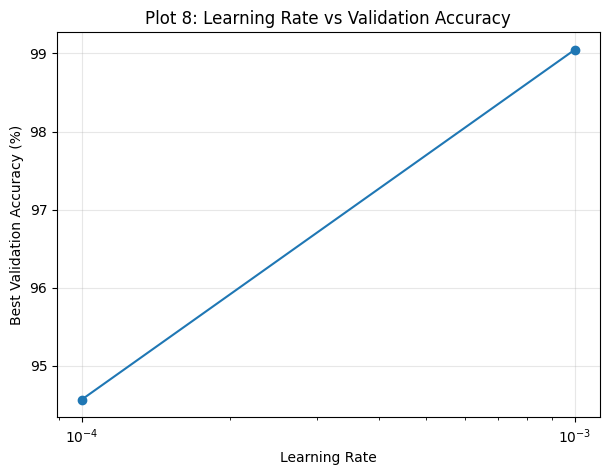

In [ ]:
# ============================================================
# Task 6: Hyperparameter Tuning
# ============================================================
EPOCHS_HP = 12

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

# ---- Plot 8: Learning Rate vs Validation Accuracy ----
learning_rates = [0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"\n--- Learning Rate: {lr} ---")
    tf.keras.backend.clear_session()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HP, verbose=1)
    lr_results[lr] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7, 5))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.savefig('plot8_lr_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---- Plot 9: Batch Size vs Validation Accuracy ----
batch_sizes = [16, 32, 64]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    train_ds_bs = ds_train.shuffle(1000, seed=SEED).map(
        lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds_bs = ds_val.map(
        lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)

    tf.keras.backend.clear_session()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds_bs, validation_data=val_ds_bs, epochs=EPOCHS_HP, verbose=1)
    bs_results[bs] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7, 5))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot9_batchsize_valacc.eps', dpi=150, bbox_inches='tight')
plt.show()


--- Batch Size: 16 ---
Epoch 1/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.6851 - loss: 1.1721 - val_accuracy: 0.9117 - val_loss: 0.3234
Epoch 2/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.8899 - loss: 0.3688 - val_accuracy: 0.9361 - val_loss: 0.1978
Epoch 3/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.9219 - loss: 0.2578 - val_accuracy: 0.9647 - val_loss: 0.1431
Epoch 4/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.9419 - loss: 0.1858 - val_accuracy: 0.9620 - val_loss: 0.1186
Epoch 5/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.9586 - loss: 0.1410 - val_accuracy: 0.9755 - val_loss: 0.0812
Epoch 6/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9613 - loss: 0.1184 - val_accuracy: 0.9769 - val_loss: 0.0783
Epoch 7/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.9694 - loss: 0.0916 - val_accuracy: 0.9851 - val_loss: 0.0555
Epoch 8/12
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy:

---
## Part 2 — Task 6 (continued) + Task 7 (from `CS3807_Exp5_Remaining_Tasks.ipynb`)
---

# CS3807 Experiment 5 — Remaining Tasks
This notebook picks up from where the previous session left off.
**Plots 1–8 are already done** (saved as images from earlier runs) — this notebook only covers:
- Task 6 remaining: Plot 9 (Batch Size), Plot 10 (Dropout Rate)
- Task 7: Transfer Learning / Fine-Tuning (Plots 11–12)

⚠️ **Restart points are marked clearly below.** Restart the runtime (`Runtime → Restart session`) at each marked point, then continue from the next cell — do not skip Step 0 after a restart, or Drive won't be mounted and `save_result` will fail.


## Step 0 — Run this FIRST in every fresh runtime (mount Drive + checkpoint helpers)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle, os
CKPT_DIR = '/content/drive/MyDrive/CS3807_Exp5'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_result(name, data):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {path}")

def load_result(name):
    with open(os.path.join(CKPT_DIR, f"{name}.pkl"), 'rb') as f:
        return pickle.load(f)

def list_saved():
    return sorted(f for f in os.listdir(CKPT_DIR) if f.endswith('.pkl'))

print("Already saved:", list_saved())

Mounted at /content/drive
Already saved: []


## Step 1 — Installs (once per fresh VM)\nAfter this cell finishes: **Runtime → Restart session**, then re-run Step 0 above before continuing.

In [ ]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata importlib_resources

## Step 2 — Task 1 Setup (dataset + preprocessing)\nRun this every fresh session. The dataset itself is cached on Google's servers per-VM, so this is quick, but note a brand-new Colab VM will re-download it once.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features['label'].num_classes
print("Number of classes (breeds):", num_classes)

train_size = int(0.8 * ds_info.splits['train'].num_examples)
ds_train_full = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full.take(train_size)
ds_val = ds_train_full.skip(train_size)

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

class_names = ds_info.features['label'].names
print("Setup complete. Train size:", train_size)


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of classes (breeds): 37
Setup complete. Train size: 2944


---
## Task 6 (continued) — Plot 9: Batch Size vs Validation Accuracy


In [ ]:
from tensorflow.keras import layers, models
import gc

EPOCHS_HP = 10

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

batch_sizes = [16, 32, 64]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    train_ds_bs = ds_train.shuffle(1000, seed=SEED).map(
        lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)
    val_ds_bs = ds_val.map(
        lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(bs).prefetch(tf.data.AUTOTUNE)

    tf.keras.backend.clear_session(); gc.collect()
    model = build_hp_model(dropout_rate=0.25)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds_bs, validation_data=val_ds_bs, epochs=EPOCHS_HP, verbose=1)
    bs_results[bs] = max(history.history['val_accuracy']) * 100

    save_result('bs_results_partial', bs_results)
    del model, history, train_ds_bs, val_ds_bs
    tf.keras.backend.clear_session(); gc.collect()

save_result('bs_results_final', bs_results)
print(bs_results)



--- Batch Size: 16 ---
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.7075 - loss: 1.1280 - val_accuracy: 0.9076 - val_loss: 0.3461
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.8852 - loss: 0.3600 - val_accuracy: 0.9389 - val_loss: 0.2036
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9171 - loss: 0.2417 - val_accuracy: 0.9538 - val_loss: 0.1452
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9433 - loss: 0.1820 - val_accuracy: 0.9592 - val_loss: 0.1299
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.9528 - loss: 0.1444 - val_accuracy: 0.9742 - val_loss: 0.0846
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9640 - loss: 0.1221 - val_accuracy: 0.9728 - val_loss: 0.0933
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - accuracy: 0.9715 - loss: 0.0990 - val_accuracy: 0.9796 - val_loss: 0.0713
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy:

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot9_batchsize_valacc.png', dpi=150, bbox_inches='tight')
plt.show()


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0, Step 2 (Task 1 setup), before continuing to Plot 10.


## Task 6 (continued) — Plot 10: Dropout Rate vs Validation Accuracy
Requires `build_hp_model` from the Plot 9 cell above — if you restarted, run that function definition cell again (just the `def build_hp_model` part) or re-run the whole Plot 9 code cell (it will just redo the sweep; comment it out if you already have `bs_results_final` saved and don't want to redo it).


In [ ]:
from tensorflow.keras import layers, models
import gc

EPOCHS_HP = 10

def build_hp_model(dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

dropout_rates = [0, 0.25, 0.5]
dropout_results = {}

for dr in dropout_rates:
    print(f"\n--- Dropout Rate: {dr} ---")
    tf.keras.backend.clear_session(); gc.collect()
    model = build_hp_model(dropout_rate=dr)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HP, verbose=1)
    dropout_results[dr] = max(history.history['val_accuracy']) * 100

    save_result('dropout_results_partial', dropout_results)
    del model, history
    tf.keras.backend.clear_session(); gc.collect()

save_result('dropout_results_final', dropout_results)
print(dropout_results)


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(list(dropout_results.keys()), list(dropout_results.values()), marker='o')
plt.xlabel('Dropout Rate')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.savefig('plot10_dropout_valacc.png', dpi=150, bbox_inches='tight')
plt.show()


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2 before continuing to Task 7.

## Task 7 — Transfer Learning and Fine-Tuning (Plots 11–12)
**Case A (Feature Extraction):** base frozen, only new classifier head trained.
**Case B (Fine-Tuning):** unfreeze the top layers of the pretrained base, train with a much smaller learning rate.


In [ ]:
from tensorflow.keras import layers, models
import gc

EPOCHS_FE = 10   # feature extraction phase
EPOCHS_FT = 10   # fine-tuning phase

# ---- Case A: Feature Extraction ----
tf.keras.backend.clear_session(); gc.collect()

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("=== Feature Extraction ===")
history_fe = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE, verbose=1)

save_result('history_feature_extraction', history_fe.history)


=== Feature Extraction ===
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.6240 - loss: 1.4669 - val_accuracy: 0.9144 - val_loss: 0.3416
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - accuracy: 0.8740 - loss: 0.4098 - val_accuracy: 0.9226 - val_loss: 0.2380
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.9147 - loss: 0.2751 - val_accuracy: 0.9470 - val_loss: 0.1607
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9341 - loss: 0.2200 - val_accuracy: 0.9660 - val_loss: 0.1319
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.9457 - loss: 0.1782 - val_accuracy: 0.9742 - val_loss: 0.0928
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.9671 - loss: 0.1197 - val_accuracy: 0.9796 - val_loss: 0.0799
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9664 - loss: 0.1062 - val_accuracy: 0.9783 - val_loss: 0.0659
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.969

In [ ]:
# ---- Case B: Fine-Tuning ----
# Unfreeze the top N layers of the base model, keep the rest frozen
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30  # unfreeze last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Much smaller learning rate for fine-tuning, per the lab doc's guidance
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("=== Fine-Tuning ===")
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, verbose=1)

save_result('history_fine_tuning', history_ft.history)


=== Fine-Tuning ===
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 226ms/step - accuracy: 0.9110 - loss: 0.2661 - val_accuracy: 0.9973 - val_loss: 0.0252
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.9372 - loss: 0.1963 - val_accuracy: 0.9973 - val_loss: 0.0243
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.9538 - loss: 0.1548 - val_accuracy: 0.9959 - val_loss: 0.0262
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.9586 - loss: 0.1386 - val_accuracy: 0.9932 - val_loss: 0.0292
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - accuracy: 0.9626 - loss: 0.1315 - val_accuracy: 0.9946 - val_loss: 0.0277
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9667 - loss: 0.1183 - val_accuracy: 0.9932 - val_loss: 0.0264
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.9698 - loss: 0.1036 - val_accuracy: 0.9973 - val_loss: 0.0168
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - accuracy: 0.9691 - los

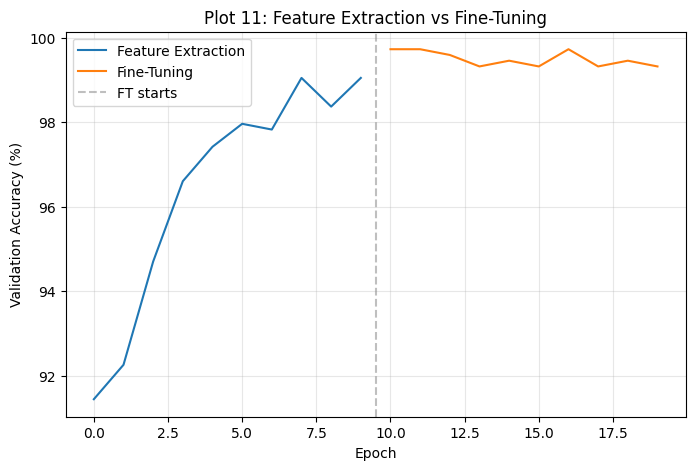

In [ ]:
# ---- Plot 11: Feature Extraction vs Fine-Tuning ----
fe_acc = [a * 100 for a in history_fe.history['val_accuracy']]
ft_acc = [a * 100 for a in history_ft.history['val_accuracy']]
# Fine-tuning continues from where feature extraction left off, in terms of epoch count
ft_epochs = list(range(len(fe_acc), len(fe_acc) + len(ft_acc)))

plt.figure(figsize=(8, 5))
plt.plot(range(len(fe_acc)), fe_acc, label='Feature Extraction')
plt.plot(ft_epochs, ft_acc, label='Fine-Tuning')
plt.axvline(x=len(fe_acc)-0.5, color='gray', linestyle='--', alpha=0.5, label='FT starts')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot11_fe_vs_ft.png', dpi=150, bbox_inches='tight')
plt.show()


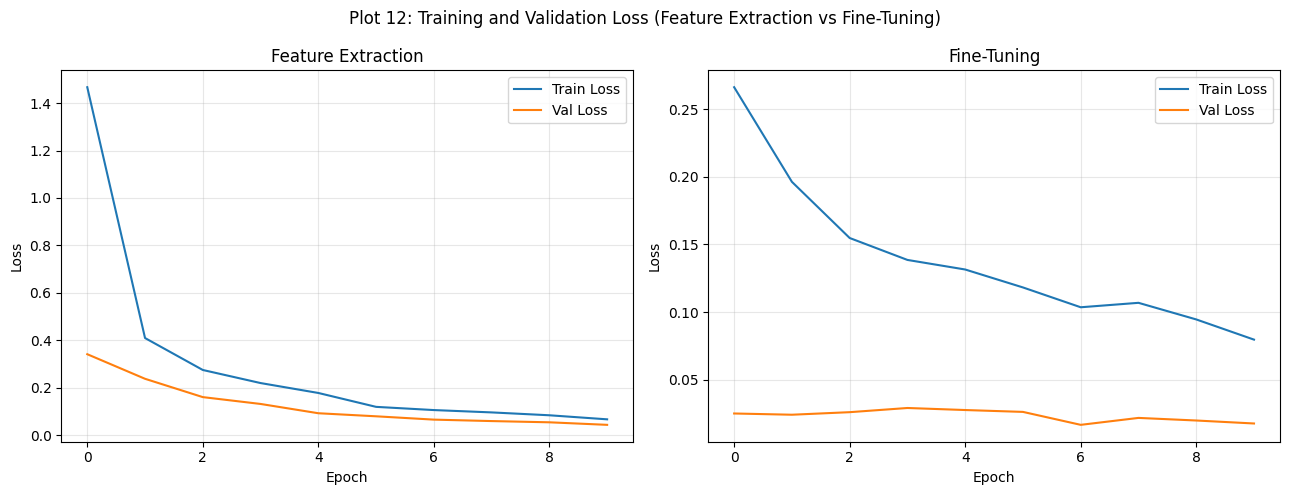

Model saved to Drive.


In [ ]:
# ---- Plot 12: Training and Validation Loss (before vs after fine-tuning) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_fe.history['loss'], label='Train Loss')
axes[0].plot(history_fe.history['val_loss'], label='Val Loss')
axes[0].set_title('Feature Extraction')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ft.history['loss'], label='Train Loss')
axes[1].plot(history_ft.history['val_loss'], label='Val Loss')
axes[1].set_title('Fine-Tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Plot 12: Training and Validation Loss (Feature Extraction vs Fine-Tuning)')
plt.tight_layout()
plt.savefig('plot12_fe_ft_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the fine-tuned model in case Task 8/9 need it later
model.save('/content/drive/MyDrive/CS3807_Exp5/finetuned_model.keras')
print("Model saved to Drive.")


---
### Discussion note for Plot 11/12 (the doc asks you to explain this)
Fine-tuning uses a **much smaller learning rate (1e-5 vs 1e-3)** because the unfrozen base layers already hold well-tuned ImageNet weights — large updates at this stage would wreck those pretrained features ("catastrophic forgetting") rather than gently adapting them to the pet-breed task.

---
**Next:** once Plots 11–12 look right, download them and we'll move to **Task 8: 5-Fold Cross-Validation (Plot 13)**.


---
## Part 3 — Tasks 8, 9, 10 + Additional Exercise (from `CS3807_Exp5_Tasks_8_9_10.ipynb`)
---

# CS3807 Experiment 5 — Tasks 8, 9, 10
Continuation notebook. Picks up right after Plots 11–12 (Task 7).
Covers:
- **Task 8**: 5-Fold Cross-Validation — Plot 13, configuration table
- **Task 9**: Final Model Evaluation — confusion matrix (Plot 14), precision/recall/F1, params, training time
- **Task 10**: Overall Results table, 23 Discussion Questions, Additional Exercise (2 new configs via 5-fold CV)

⚠️ **Restart points are marked.** Restart the runtime at each marked point, then re-run Step 0 and Step 2 before continuing — otherwise Drive won't be mounted / dataset objects won't exist.

## Step 0 — Run this FIRST in every fresh runtime (mount Drive + checkpoint helpers)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle, os
CKPT_DIR = '/content/drive/MyDrive/CS3807_Exp5'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_result(name, data):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {path}")

def load_result(name):
    with open(os.path.join(CKPT_DIR, f"{name}.pkl"), 'rb') as f:
        return pickle.load(f)

def list_saved():
    return sorted(f for f in os.listdir(CKPT_DIR) if f.endswith('.pkl'))

print("Already saved:", list_saved())

Mounted at /content/drive
Already saved: []


## Step 1 — Installs (once per fresh VM)
After this cell finishes: **Runtime → Restart session**, then re-run Step 0 before continuing.

In [ ]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata importlib_resources scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.


## Step 2 — Task 1 Setup (dataset + preprocessing)
Run this every fresh session (same as earlier notebooks — kept identical so variable names line up).

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time, gc

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names
print("Number of classes (breeds):", num_classes)

train_size = int(0.8 * ds_info.splits['train'].num_examples)
ds_train_full_shuffled = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full_shuffled.take(train_size)
ds_val = ds_train_full_shuffled.skip(train_size)

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

print("Setup complete.")

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.V2OEDJ_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.V2OEDJ_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of classes (breeds): 37
Setup complete.


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2, before continuing to Task 8.

## Task 8 — 5-Fold Cross-Validation (Plot 13)
The doc says: pick 3–4 promising configurations from your earlier studies (Tasks 2–6) and evaluate each with 5-fold CV **on the training data only** — the test set stays untouched.

**Edit `CONFIGS` below** to reflect what actually won in your earlier plots (best init strategy is already baked into how MobileNetV2 loads its pretrained weights, so the CV configs mainly vary regularization / optimizer / batch size / dropout / BN, per the doc's guidance). The 4 defaults below are reasonable starting picks if you haven't decided yet — swap in your real winners.

In [ ]:
# ---- Step A: materialize the full TRAIN split as numpy arrays (needed for KFold indexing) ----
# We use ds_train_full (all ~3680 train images) — NOT ds_test — for cross-validation.

X_list, y_list = [], []
for image, label in tfds.as_numpy(ds_train_full):
    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)).numpy().astype('uint8')
    X_list.append(img)
    y_list.append(label)

X_all = np.stack(X_list)          # uint8, raw resized pixels (preprocess_input applied later, per-fold)
y_all = np.array(y_list)
print("X_all:", X_all.shape, "y_all:", y_all.shape)

np.save(os.path.join(CKPT_DIR, 'cv_X_all.npy'), X_all)
np.save(os.path.join(CKPT_DIR, 'cv_y_all.npy'), y_all)
print("Saved CV arrays to Drive.")

X_all: (3680, 224, 224, 3) y_all: (3680,)
Saved CV arrays to Drive.


In [ ]:
# ---- Step B: define candidate configurations (EDIT to match your best findings from Tasks 2-6) ----
CONFIGS = {
    'C1': dict(optimizer='adam', lr=1e-3, dropout=0.25, batch_size=32, use_bn=False),   # baseline-ish
    'C2': dict(optimizer='adam', lr=1e-3, dropout=0.5,  batch_size=32, use_bn=True),    # best regularization guess
    'C3': dict(optimizer='adam', lr=1e-4, dropout=0.25, batch_size=16, use_bn=False),   # best LR/batch guess
    'C4': dict(optimizer='rmsprop', lr=1e-3, dropout=0.25, batch_size=64, use_bn=False),# best optimizer guess
}
EPOCHS_CV = 8  # keep modest - 4 configs x 5 folds = 20 training runs

def build_cv_model(cfg):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    if cfg['use_bn']:
        x = tf.keras.layers.BatchNormalization()(x)
    if cfg['dropout'] > 0:
        x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)

    if cfg['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=cfg['lr'])
    elif cfg['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=cfg['lr'], momentum=0.9)
    elif cfg['optimizer'] == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=cfg['lr'])
    else:
        raise ValueError(cfg['optimizer'])

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def make_fold_pipeline(X, y, indices, batch_size, augment):
    Xi, yi = X[indices], y[indices]
    ds = tf.data.Dataset.from_tensor_slices((Xi, yi))
    if augment:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda im, lb: preprocess(im, lb, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
# ---- Step C: run 5-fold CV for each config (checkpoints after every fold) ----
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_indices = list(kf.split(X_all))  # same splits reused across all configs -> fair comparison

cv_results = {}   # cv_results[config_name] = {'fold_acc': [...], 'time_sec': total_time}
try:
    cv_results = load_result('cv_results_partial')
    print("Resuming from partial results:", list(cv_results.keys()))
except FileNotFoundError:
    pass

for cfg_name, cfg in CONFIGS.items():
    if cfg_name in cv_results and len(cv_results[cfg_name]['fold_acc']) == 5:
        print(f"Skipping {cfg_name} (already complete).")
        continue

    print(f"\n========== Config {cfg_name}: {cfg} ==========")
    fold_acc = cv_results.get(cfg_name, {}).get('fold_acc', [])
    start_time = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(fold_indices):
        if fold_i < len(fold_acc):
            continue  # already done for this config
        print(f"-- Fold {fold_i + 1}/5 --")
        tf.keras.backend.clear_session(); gc.collect()

        train_fold_ds = make_fold_pipeline(X_all, y_all, train_idx, cfg['batch_size'], augment=True)
        val_fold_ds   = make_fold_pipeline(X_all, y_all, val_idx,   cfg['batch_size'], augment=False)

        model = build_cv_model(cfg)
        history = model.fit(train_fold_ds, validation_data=val_fold_ds,
                             epochs=EPOCHS_CV, verbose=1)
        best_val_acc = max(history.history['val_accuracy']) * 100
        fold_acc.append(best_val_acc)

        cv_results[cfg_name] = {'fold_acc': fold_acc, 'time_sec': time.time() - start_time}
        save_result('cv_results_partial', cv_results)

        del model, history
        tf.keras.backend.clear_session(); gc.collect()

    cv_results[cfg_name]['time_sec'] = time.time() - start_time
    save_result('cv_results_partial', cv_results)
    print(f"{cfg_name} done: {cv_results[cfg_name]['fold_acc']}")

save_result('cv_results_final', cv_results)
print("\nAll configs complete:", cv_results)


========== Config C1: {'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.25, 'batch_size': 32, 'use_bn': False} ==========
-- Fold 1/5 --
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 103ms/step - accuracy: 0.6491 - loss: 1.3494 - val_accuracy: 0.8723 - val_loss: 0.4045
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8849 - loss: 0.3706 - val_accuracy: 0.9158 - val_loss: 0.3074
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9300 - loss: 0.2344 - val_accuracy: 0.9171 - val_loss: 0.2599
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9395 - loss: 0.1889 - val_accuracy: 0.8954 - val_loss: 0.2942
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9596 - loss: 0.1367 - val_accuracy: 0.9185 - val_loss: 0.2506
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9694 - loss: 0.1057 - val_accuracy: 0.8981 - val_loss: 0.2881
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accu

In [ ]:
# ---- Step D: configuration table (F1-F5, Mean +- SD) ----
rows = []
for cfg_name, res in cv_results.items():
    accs = res['fold_acc']
    row = {'Configuration': cfg_name}
    for i, a in enumerate(accs):
        row[f'F{i+1}'] = round(a, 2)
    row['Mean'] = round(np.mean(accs), 2)
    row['SD'] = round(np.std(accs), 2)
    row['Mean ± SD'] = f"{np.mean(accs):.2f} ± {np.std(accs):.2f}"
    row['Time (s)'] = round(res['time_sec'], 1)
    rows.append(row)

cv_table = pd.DataFrame(rows).sort_values('Mean', ascending=False).reset_index(drop=True)
print(cv_table.to_string(index=False))
cv_table.to_csv('/content/drive/MyDrive/CS3807_Exp5/plot13_cv_table.csv', index=False)
cv_table

Configuration    F1    F2    F3    F4    F5  Mean   SD    Mean ± SD  Time (s)
           C4 92.12 91.30 92.39 91.58 92.12 91.90 0.40 91.90 ± 0.40     277.2
           C2 92.39 91.17 91.30 91.30 92.80 91.79 0.67 91.79 ± 0.67     250.9
           C1 91.85 90.08 90.76 91.44 91.85 91.20 0.68 91.20 ± 0.68     279.2
           C3 90.22 90.49 90.35 91.17 89.81 90.41 0.44 90.41 ± 0.44     293.8


,Configuration,F1,F2,F3,F4,F5,Mean,SD,Mean ± SD,Time (s)
0,C4,92.12,91.30,92.39,91.58,92.12,91.90,0.40,91.90 ± 0.40,277.2
1,C2,92.39,91.17,91.30,91.30,92.80,91.79,0.67,91.79 ± 0.67,250.9
2,C1,91.85,90.08,90.76,91.44,91.85,91.20,0.68,91.20 ± 0.68,279.2
3,C3,90.22,90.49,90.35,91.17,89.81,90.41,0.44,90.41 ± 0.44,293.8


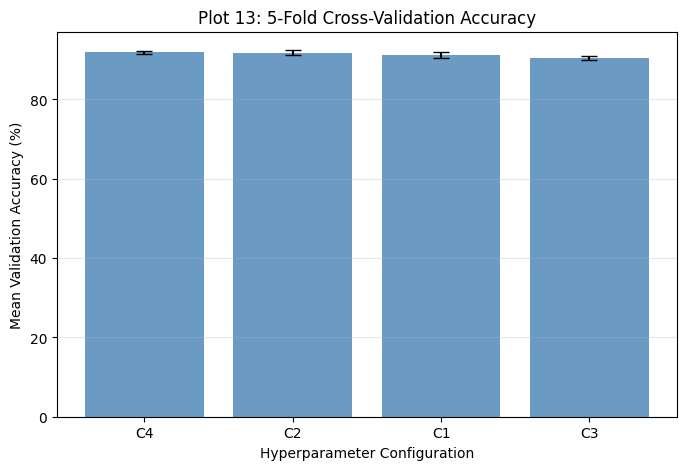

Best configuration by mean CV accuracy: C4
(Also check SD - a slightly lower mean with much lower SD can be the more 'reliable' pick.)
Saved: /content/drive/MyDrive/CS3807_Exp5/best_config_name.pkl


In [ ]:
# ---- Plot 13: 5-Fold CV Accuracy with SD error bars ----
plt.figure(figsize=(8, 5))
names = cv_table['Configuration'].tolist()
means = cv_table['Mean'].tolist()
sds = cv_table['SD'].tolist()
plt.bar(names, means, yerr=sds, capsize=6, alpha=0.8, color='steelblue')
plt.xlabel('Hyperparameter Configuration')
plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy')
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot13_cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

best_config_name = cv_table.iloc[0]['Configuration']
print(f"Best configuration by mean CV accuracy: {best_config_name}")
print(f"(Also check SD - a slightly lower mean with much lower SD can be the more 'reliable' pick.)")
save_result('best_config_name', best_config_name)

**Inference to write for Plot 13:** which config has the best mean accuracy, which has the lowest variability (SD), and whether they're the same config — this is exactly what Discussion Question 22/23 below ask about.

---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2, before continuing to Task 9.

## Task 9 — Final Model Evaluation (Plot 14)
Retrain the CV-selected configuration on the **complete training data** (all of `ds_train_full`, no held-out val), then evaluate **once** on the untouched test set.

In [ ]:
# ---- Step A: recall the best config from Task 8 ----
best_config_name = load_result('best_config_name')
CONFIGS = {
    'C1': dict(optimizer='adam', lr=1e-3, dropout=0.25, batch_size=32, use_bn=False),
    'C2': dict(optimizer='adam', lr=1e-3, dropout=0.5,  batch_size=32, use_bn=True),
    'C3': dict(optimizer='adam', lr=1e-4, dropout=0.25, batch_size=16, use_bn=False),
    'C4': dict(optimizer='rmsprop', lr=1e-3, dropout=0.25, batch_size=64, use_bn=False),
}
best_cfg = CONFIGS[best_config_name]
print("Selected configuration:", best_config_name, best_cfg)

def build_cv_model(cfg):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    if cfg['use_bn']:
        x = tf.keras.layers.BatchNormalization()(x)
    if cfg['dropout'] > 0:
        x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    if cfg['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=cfg['lr'])
    elif cfg['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=cfg['lr'], momentum=0.9)
    elif cfg['optimizer'] == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=cfg['lr'])
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

Selected configuration: C4 {'optimizer': 'rmsprop', 'lr': 0.001, 'dropout': 0.25, 'batch_size': 64, 'use_bn': False}


In [ ]:
# ---- Step B: retrain on the FULL training data, then fine-tune (matches Task 7's Case B strategy) ----
EPOCHS_FINAL_FE = 12
EPOCHS_FINAL_FT = 8

full_train_ds = make_pipeline(ds_train_full, shuffle=True, augment=True, batch_size=best_cfg['batch_size'])

tf.keras.backend.clear_session(); gc.collect()
t0 = time.time()

final_model, final_base = build_cv_model(best_cfg)
print("=== Final model: feature-extraction phase on full training data ===")
final_model.fit(full_train_ds, epochs=EPOCHS_FINAL_FE, verbose=1)

# Fine-tune, same recipe as Task 7 (unfreeze last ~30 layers, small LR)
final_base.trainable = True
fine_tune_at = len(final_base.layers) - 30
for layer in final_base.layers[:fine_tune_at]:
    layer.trainable = False
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])
print("=== Final model: fine-tuning phase on full training data ===")
final_model.fit(full_train_ds, epochs=EPOCHS_FINAL_FT, verbose=1)

training_time_sec = time.time() - t0
print(f"Total final training time: {training_time_sec:.1f} sec")

final_model.save('/content/drive/MyDrive/CS3807_Exp5/final_model.keras')
save_result('training_time_sec', training_time_sec)
print("Final model saved.")

=== Final model: feature-extraction phase on full training data ===
Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - accuracy: 0.6891 - loss: 1.2234
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.8785 - loss: 0.4044
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.9228 - loss: 0.2579
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.9383 - loss: 0.1937
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9495 - loss: 0.1488
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.9636 - loss: 0.1147
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.9701 - loss: 0.0973
Epoch 8/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.9788 - loss: 0.0718
Epoch 9/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.9826 - loss: 0.0597
Epoch 10/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9829 - loss: 0.0549
Epoch 11/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accura

In [ ]:
# ---- Step C: evaluate ONCE on the untouched test set ----
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

total_params = final_model.count_params()
trainable_params = sum(np.prod(v.shape) for v in final_model.trainable_variables)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,.0f}")
print(f"Training time        : {training_time_sec:.1f} sec")

final_metrics = dict(test_accuracy=test_accuracy, precision=precision, recall=recall, f1=f1,
                      total_params=total_params, trainable_params=int(trainable_params),
                      training_time_sec=training_time_sec)
save_result('final_metrics', final_metrics)

Test Accuracy : 89.37%
Precision (macro): 0.9003
Recall (macro)   : 0.8933
F1-score (macro) : 0.8929
Total parameters    : 2,426,725
Trainable parameters: 1,695,141
Training time        : 284.4 sec
Saved: /content/drive/MyDrive/CS3807_Exp5/final_metrics.pkl


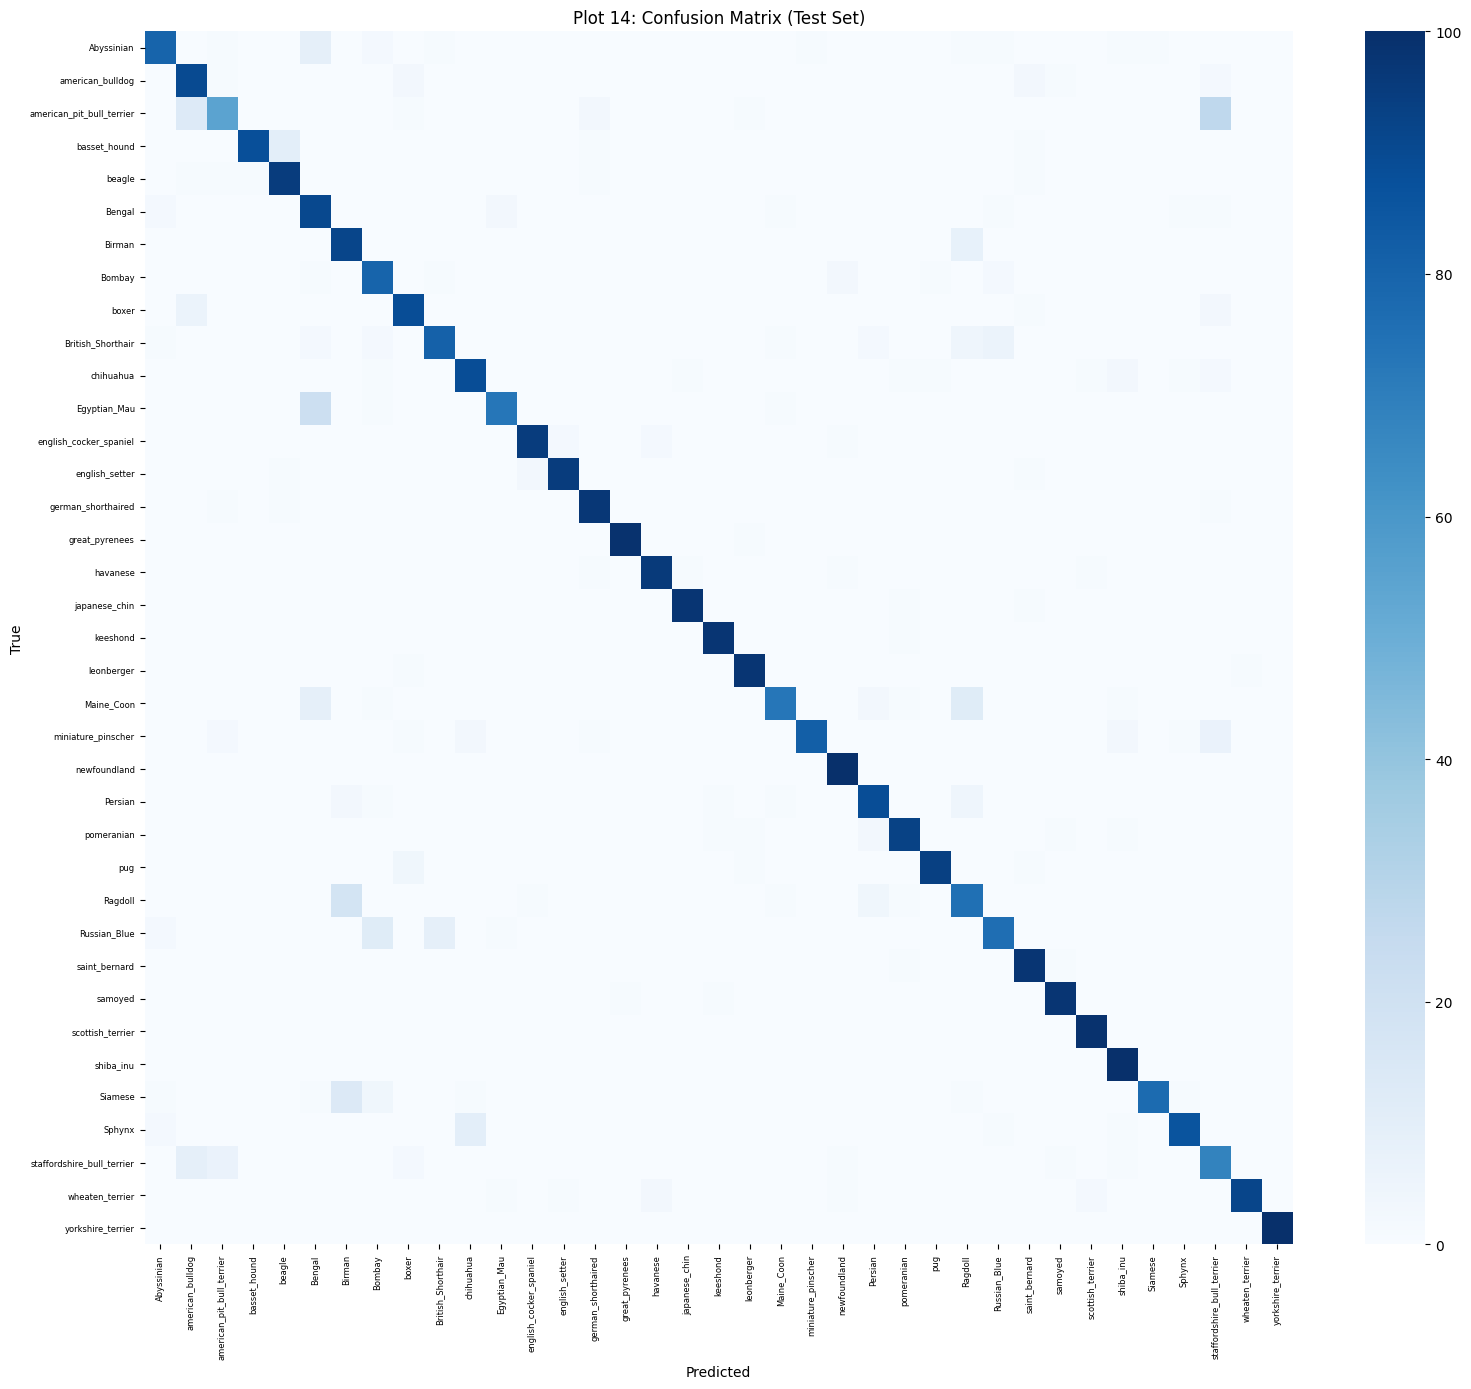

Most frequently confused class pairs (true -> predicted, count):
  american_pit_bull_terrier -> staffordshire_bull_terrier : 27
  Egyptian_Mau              -> Bengal                    : 22
  Ragdoll                   -> Birman                    : 18
  Siamese                   -> Birman                    : 14
  american_pit_bull_terrier -> american_bulldog          : 13
  Maine_Coon                -> Ragdoll                   : 12
  Russian_Blue              -> Bombay                    : 12
  Sphynx                    -> chihuahua                 : 10
  basset_hound              -> beagle                    : 10
  staffordshire_bull_terrier -> american_bulldog          : 9

Best classified classes: [('scottish_terrier', np.float64(100.0)), ('shiba_inu', np.float64(100.0)), ('newfoundland', np.float64(100.0)), ('yorkshire_terrier', np.float64(100.0)), ('great_pyrenees', np.float64(99.0))]
Worst classified classes: [('american_pit_bull_terrier', np.float64(55.0)), ('Maine_Coon', np.f

In [ ]:
# ---- Plot 14: Confusion Matrix ----
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Plot 14: Confusion Matrix (Test Set)')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot14_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most-confused class pairs (off-diagonal, top 10)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
top_confused_idx = np.dstack(np.unravel_index(np.argsort(-cm_off, axis=None), cm_off.shape))[0][:10]
print("Most frequently confused class pairs (true -> predicted, count):")
for i, j in top_confused_idx:
    if cm_off[i, j] > 0:
        print(f"  {class_names[i]:25s} -> {class_names[j]:25s} : {cm_off[i, j]}")

# Per-class accuracy, best and worst classified
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes = np.argsort(-per_class_acc)[:5]
worst_classes = np.argsort(per_class_acc)[:5]
print("\nBest classified classes:", [(class_names[i], round(per_class_acc[i]*100,1)) for i in best_classes])
print("Worst classified classes:", [(class_names[i], round(per_class_acc[i]*100,1)) for i in worst_classes])

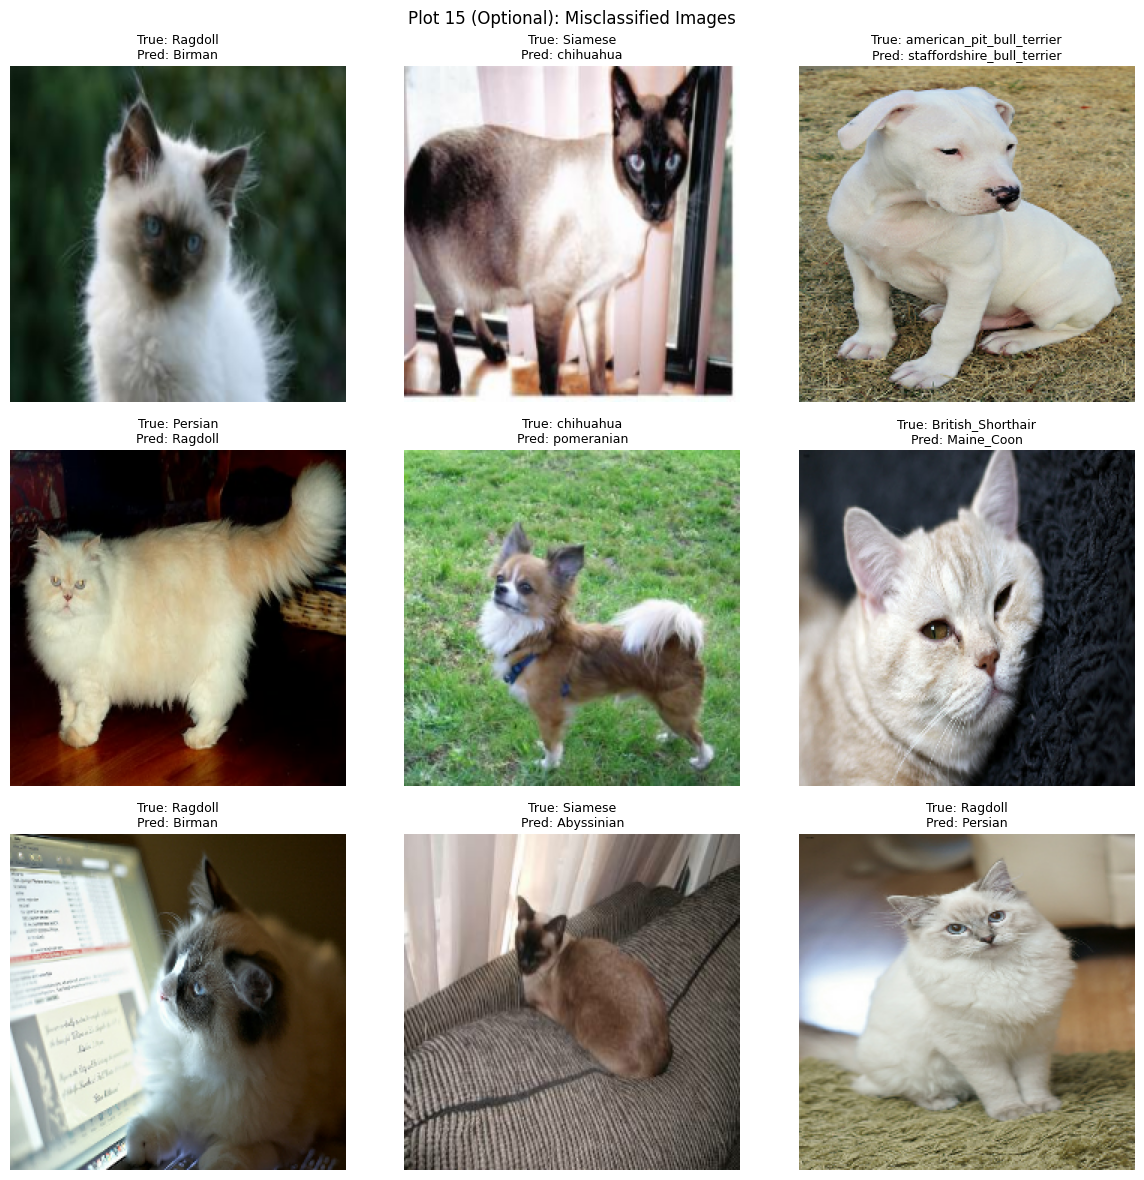

In [ ]:
# ---- Optional Plot 15: Misclassified images ----
mis_idx = np.where(y_true != y_pred)[0]
sample_idx = np.random.RandomState(SEED).choice(mis_idx, size=min(9, len(mis_idx)), replace=False)

# Rebuild an unnormalized version of the test set for display purposes
test_ds_display = ds_test.map(lambda im, lb: (tf.image.resize(im, (IMG_SIZE, IMG_SIZE)), lb))
test_images_list, test_labels_list = [], []
for im, lb in tfds.as_numpy(test_ds_display):
    test_images_list.append(im.astype('uint8'))
    test_labels_list.append(lb)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(test_images_list[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
plt.suptitle('Plot 15 (Optional): Misclassified Images')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot15_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 10 — Overall Results, Discussion Questions, Additional Exercise

### Overall Results table
This pulls together the best numbers from every stage. Cells marked `# FILL IN` need the actual values you read off your earlier plots (Tasks 2–6) — those runs weren't checkpointed with `save_result`, so they can't be auto-loaded here.

In [ ]:
cv_results = load_result('cv_results_final')
final_metrics = load_result('final_metrics')
best_config_name = load_result('best_config_name')

overall_rows = [
    # Configuration        , CV Accuracy (%)                 , SD                              , Test Accuracy (%)         , Training Time (s)
    ['Baseline (no reg, default init/opt)', None, None, None, None],   # FILL IN from Task 2/3 plots
    ['Best Initialization',                 None, None, None, None],   # FILL IN from Plot 1/2
    ['Best Regularization',                 None, None, None, None],   # FILL IN from Plot 3/4/5
    ['Best Optimizer',                      None, None, None, None],   # FILL IN from Plot 6/7
    ['Best Hyperparameters',                None, None, None, None],   # FILL IN from Plot 8/9/10
    [f'Best CV Config ({best_config_name})',
        round(np.mean(cv_results[best_config_name]['fold_acc']), 2),
        round(np.std(cv_results[best_config_name]['fold_acc']), 2),
        None, None],
    ['Final Fine-Tuned Model',
        None, None,
        round(final_metrics['test_accuracy'] * 100, 2),
        round(final_metrics['training_time_sec'], 1)],
]

overall_df = pd.DataFrame(overall_rows, columns=['Configuration', 'CV Accuracy (%)', 'SD', 'Test Accuracy (%)', 'Training Time (s)'])
overall_df.to_csv('/content/drive/MyDrive/CS3807_Exp5/overall_results_table.csv', index=False)
overall_df

,Configuration,CV Accuracy (%),SD,Test Accuracy (%),Training Time (s)
0,"Baseline (no reg, default init/opt)",NaN,NaN,NaN,NaN
1,Best Initialization,NaN,NaN,NaN,NaN
2,Best Regularization,NaN,NaN,NaN,NaN
3,Best Optimizer,NaN,NaN,NaN,NaN
4,Best Hyperparameters,NaN,NaN,NaN,NaN
5,Best CV Config (C4),91.9,0.4,NaN,NaN
6,Final Fine-Tuned Model,NaN,NaN,89.37,284.4


In [ ]:
# ---- Additional Exercise: 2 new configurations ----
NEW_CONFIGS = {
    'C5': dict(optimizer='sgd', lr=1e-3, dropout=0.5, batch_size=32, use_bn=True),      # heavier reg + momentum SGD
    'C6': dict(optimizer='adam', lr=1e-4, dropout=0.0, batch_size=64, use_bn=True),     # low LR, no dropout, BN only, larger batch
}

for cfg_name, cfg in NEW_CONFIGS.items():
    if cfg_name in cv_results and len(cv_results[cfg_name]['fold_acc']) == 5:
        print(f"Skipping {cfg_name} (already complete).")
        continue
    print(f"\n========== Config {cfg_name}: {cfg} ==========")
    fold_acc = cv_results.get(cfg_name, {}).get('fold_acc', [])
    start_time = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(fold_indices):
        if fold_i < len(fold_acc):
            continue
        print(f"-- Fold {fold_i + 1}/5 --")
        tf.keras.backend.clear_session(); gc.collect()
        train_fold_ds = make_fold_pipeline(X_all, y_all, train_idx, cfg['batch_size'], augment=True)
        val_fold_ds   = make_fold_pipeline(X_all, y_all, val_idx,   cfg['batch_size'], augment=False)
        model, _ = build_cv_model(cfg)
        history = model.fit(train_fold_ds, validation_data=val_fold_ds, epochs=EPOCHS_CV, verbose=1)
        fold_acc.append(max(history.history['val_accuracy']) * 100)
        cv_results[cfg_name] = {'fold_acc': fold_acc, 'time_sec': time.time() - start_time}
        save_result('cv_results_partial', cv_results)
        del model, history
        tf.keras.backend.clear_session(); gc.collect()

    cv_results[cfg_name]['time_sec'] = time.time() - start_time
    save_result('cv_results_partial', cv_results)

save_result('cv_results_final', cv_results)

# ---- Comparison table: original 4 configs + the 2 new ones ----
rows = []
for cfg_name, res in cv_results.items():
    accs = res['fold_acc']
    rows.append({
        'Configuration': cfg_name,
        'Mean (%)': round(np.mean(accs), 2),
        'SD': round(np.std(accs), 2),
        'Time (s)': round(res['time_sec'], 1),
        'New?': 'Yes' if cfg_name in NEW_CONFIGS else 'No',
    })
comparison_table = pd.DataFrame(rows).sort_values('Mean (%)', ascending=False).reset_index(drop=True)
comparison_table.to_csv('/content/drive/MyDrive/CS3807_Exp5/additional_exercise_comparison.csv', index=False)
comparison_table

**Write-up prompt for the exercise (fill in after running):** state whether C5 or C6 beats the Task-8 winner (`best_config_name`) on mean accuracy; then check whether that improvement (if any) survives once you also weigh in the SD (consistency) and the training time (computational cost). A config that wins on mean but has much higher SD or takes much longer to train is often *not* preferable overall — that's the judgment call the doc is asking you to make.